# Analysis of our Transformer model

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
from tqdm import tqdm
from pathlib import Path
from argparse import Namespace

module_path = Path("src").resolve()
sys.path.append(str(module_path))
from load_data import ProteinDataset, collate_fn, analyze_dataset
from new_file import custom_classifier
import classifier
import visualizing

## Set Parameters

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LEN = 128
BATCH_SIZE = 32

# Classes in dataset
label_cols = ['NO_S', 'LIP', 'S', 'TATLIP', 'PILI', 'TA']

args = {
    "max_len": MAX_LEN,
    "vocab_size": 23,
    "num_classes": len(label_cols),
    "num_heads": 4,
    "num_layers": 2,
    "embed_dim": 128,
    "attention_fn": "dot_prod",
    "Classifier": classifier.LinearClassifier,
    "classifier_reduction": "mean"
}
args = Namespace(**args)

## Load Dataset

In [3]:
# Load test dataframe
df = pd.read_csv("data/dataset_clean.csv")
analyze_dataset(df, label_cols=label_cols, sequence_col='sequence')

===== DATASET SUMMARY =====
Total rows: 25693
Total columns: 10

===== SEQUENCE LENGTH STATISTICS =====
Min length:   29
Max length:   69
Mean length:  68.90
Median length:69.00

===== LABEL DISTRIBUTION =====
NO_S                     : 19036
S                        : 3652
LIP                      : 2261
TA                       : 595
PILI                     : 113
TATLIP                   : 36

===== DONE =====


## Create Test dataset

In [4]:
# Create test data set, with same random state as during training
_, test_df = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)
analyze_dataset(test_df, label_cols=label_cols, sequence_col='sequence')

# Dataset and DataLoader
test_dataset = ProteinDataset(test_df, label_cols, seq_col="sequence", max_len=MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

===== DATASET SUMMARY =====
Total rows: 2570
Total columns: 10

===== SEQUENCE LENGTH STATISTICS =====
Min length:   29
Max length:   69
Mean length:  68.91
Median length:69.00

===== LABEL DISTRIBUTION =====
NO_S                     : 1921
S                        : 359
LIP                      : 215
TA                       : 62
PILI                     : 7
TATLIP                   : 6

===== DONE =====


## Load Model

In [5]:
# Recreate model
model = custom_classifier(args)
model.load_state_dict(torch.load("model/signalP_dot_prod_mean_best_model.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

RuntimeError: Error(s) in loading state_dict for custom_classifier:
	Unexpected key(s) in state_dict: "transformer.blocks.2.self_attn.Wq.weight", "transformer.blocks.2.self_attn.Wq.bias", "transformer.blocks.2.self_attn.Wk.weight", "transformer.blocks.2.self_attn.Wk.bias", "transformer.blocks.2.self_attn.Wv.weight", "transformer.blocks.2.self_attn.Wv.bias", "transformer.blocks.2.self_attn.Wo.weight", "transformer.blocks.2.self_attn.Wo.bias", "transformer.blocks.2.ffn.0.weight", "transformer.blocks.2.ffn.0.bias", "transformer.blocks.2.ffn.2.weight", "transformer.blocks.2.ffn.2.bias", "transformer.blocks.2.norm1.weight", "transformer.blocks.2.norm1.bias", "transformer.blocks.2.norm2.weight", "transformer.blocks.2.norm2.bias", "transformer.blocks.3.self_attn.Wq.weight", "transformer.blocks.3.self_attn.Wq.bias", "transformer.blocks.3.self_attn.Wk.weight", "transformer.blocks.3.self_attn.Wk.bias", "transformer.blocks.3.self_attn.Wv.weight", "transformer.blocks.3.self_attn.Wv.bias", "transfo

## Run Model

In [7]:
all_preds = []
all_labels = []
all_emb = []

# Wrap the DataLoader with tqdm
test_loop = tqdm(test_loader, desc="Testing", leave=True)

# Run Model
with torch.no_grad():
    for batch in test_loop:
        sequences, labels, attention_mask = [b.to(DEVICE) for b in batch]
        logits, emb = model(sequences, attention_mask)
        all_preds.append(torch.sigmoid(logits).cpu())
        all_labels.append(labels.cpu())
        all_emb.append(emb.cpu())

        # Show running number of batches
        test_loop.set_postfix({"batch": f"{len(all_labels)}/{len(test_loader)}"})

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_emb = torch.cat(all_emb)

NameError: name 'test_loader' is not defined

### Save results

In [8]:
torch.save({
    "labels": all_labels,
    "predictions": all_preds,
    "embeddings": all_emb
}, "data/results/dot_prod_results.pt")

### Load saved results

In [3]:
data = torch.load("data/results/dot_prod_results.pt")
all_labels = data["labels"]
all_preds = data["predictions"]
all_emb = data["embeddings"]


### Evaluate results

In [4]:
# Binary predictions (threshold 0.5)
preds_bin = (all_preds >= 0.5).float()

# Macro F1
macro_f1 = f1_score(all_labels, preds_bin, average="macro", zero_division=0)
print("Test Macro F1:", macro_f1)

# Per-class F1 / ROC-AUC
for i, label in enumerate(label_cols):
    f1 = f1_score(all_labels[:, i], preds_bin[:, i], zero_division=0)
    try:
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    except ValueError:
        auc = float('nan')
    print(f"{label:20s} - F1: {f1:.4f} - ROC-AUC: {auc:.4f}")

Test Macro F1: 0.7860987961698487
NO_S                 - F1: 0.9757 - ROC-AUC: 0.9814
LIP                  - F1: 0.8838 - ROC-AUC: 0.9897
S                    - F1: 0.8455 - ROC-AUC: 0.9709
TATLIP               - F1: 0.4615 - ROC-AUC: 0.9502
PILI                 - F1: 0.7500 - ROC-AUC: 0.9692
TA                   - F1: 0.8000 - ROC-AUC: 0.9694


In [ ]:


data = torch.load("data/results/signalp_linear_results.pt")

lab_idx = {'LIP': 0, 'NO_S': 1, 'PILI': 2, 'S': 3, 'TA': 4, 'TATLIP': 5}
label_cols = list(lab_idx.keys())
all_labels_int = data["all_labels"].squeeze(1).cpu() 
all_preds = torch.softmax(data["predictions"], dim=1).cpu()
all_emb = data["embeddings"]
print(all_labels_int.shape)

all_labels = torch.nn.functional.one_hot(all_labels_int, num_classes=6).cpu()
print(all_labels.shape)
all_labels_int = all_labels_int.numpy()


torch.Size([3854])
torch.Size([3854, 6])


In [6]:
# Binary predictions (threshold 0.5)
preds_bin = (all_preds >= 0.5).float()

# Macro F1
macro_f1 = f1_score(all_labels, preds_bin, average="macro", zero_division=0)
print("Test Macro F1:", macro_f1)

# Per-class F1 / ROC-AUC
for i, label in enumerate(label_cols):
    f1 = f1_score(all_labels[:, i], preds_bin[:, i], zero_division=0)
    try:
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    except ValueError:
        auc = float('nan')
    print(f"{label:20s} - F1: {f1:.4f} - ROC-AUC: {auc:.4f}")

Test Macro F1: 0.878360413442172


LIP                  - F1: 0.9367 - ROC-AUC: 0.9972
NO_S                 - F1: 0.9856 - ROC-AUC: 0.9872
PILI                 - F1: 0.9032 - ROC-AUC: 0.9996
S                    - F1: 0.9026 - ROC-AUC: 0.9868
TA                   - F1: 0.8362 - ROC-AUC: 0.9950
TATLIP               - F1: 0.7059 - ROC-AUC: 0.9826


In [7]:
print("Model summary:")
print(f"Labels are of shape:\t\t{all_labels.shape}")
print(f"Predictions are of shape:\t{all_preds.shape}")
print(f"Embeddings are of shape:\t{all_emb.shape}")

Model summary:
Labels are of shape:		torch.Size([3854, 6])
Predictions are of shape:	torch.Size([3854, 6])
Embeddings are of shape:	torch.Size([3854, 128])


## Plot results

torch.Size([3854])
tensor([19270,  3854])
CLass accuracy:  [0.91735537 0.98680097 0.93333333 0.90981964 0.83146067 0.66666667]


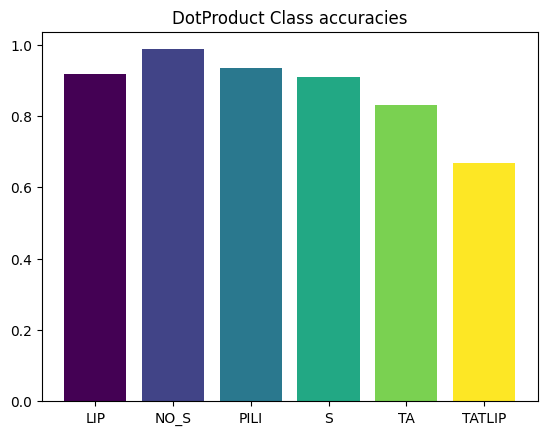

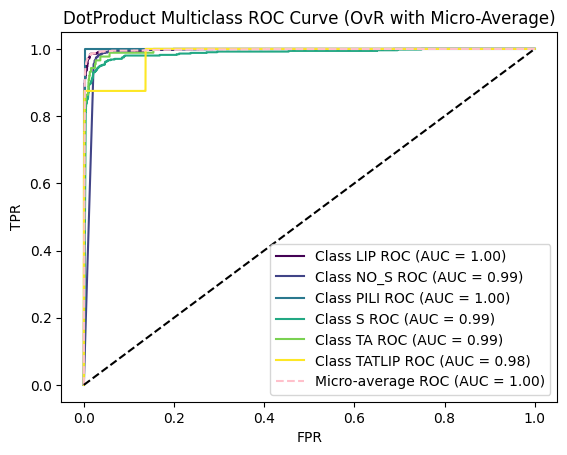

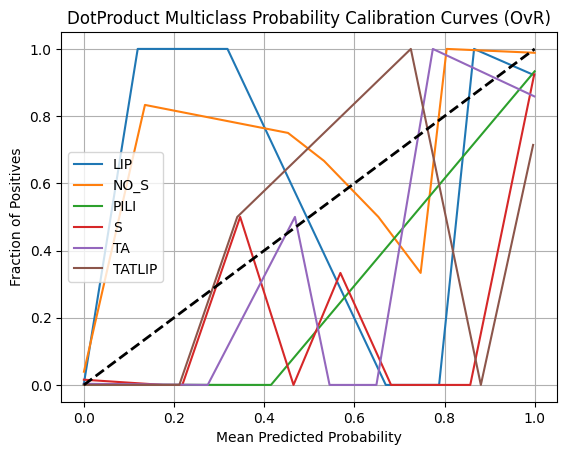

Optimal T: 0.1978515084313257


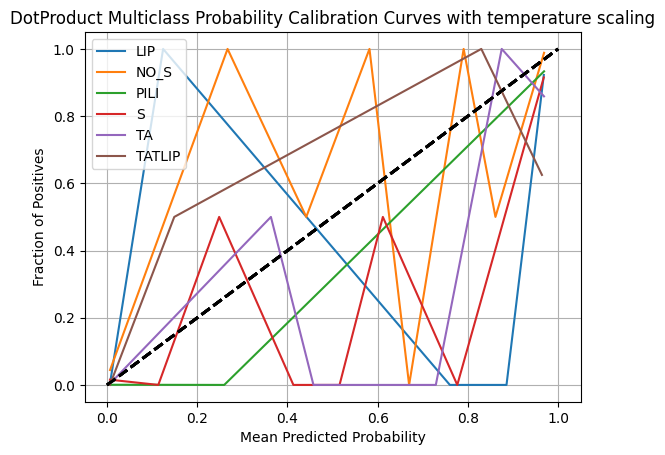

DotProduct ECE: 0.0036
DotProduct  MCE: 0.6994
DotProduct  Brier score: 0.0647
DotProduct  Log-loss: 0.1924
Variance explained:  [6.6360259e-01 2.2032180e-01 7.3995471e-02 1.8991746e-02 9.9415313e-03
 4.2989659e-03 2.4722146e-03 1.4993643e-03 9.3090301e-04 5.7837443e-04
 4.5798678e-04 4.3911932e-04 3.6574589e-04 3.2376029e-04 2.5461789e-04
 1.9742904e-04 1.6249817e-04 1.3134646e-04 1.2271805e-04 9.1168637e-05
 8.6317938e-05 7.5895601e-05 6.1865911e-05 6.0610659e-05 5.2060503e-05
 4.8817074e-05 3.5645640e-05 3.1881355e-05 3.0911531e-05 2.5840454e-05
 2.1981470e-05 2.0357524e-05 1.9406882e-05 1.7697092e-05 1.6587706e-05
 1.5630061e-05 1.4198644e-05 1.3299719e-05 1.1631789e-05 1.0555976e-05
 9.7997126e-06 9.2266373e-06 7.7554323e-06 7.5821863e-06 7.0251317e-06
 6.7134874e-06 6.6601397e-06 5.6460926e-06 5.5014575e-06 5.1748643e-06
 4.8923403e-06 4.3163745e-06 4.2044171e-06 4.0371124e-06 3.7282198e-06
 3.5194030e-06 3.2401836e-06 2.9048665e-06 2.7313874e-06 2.6508667e-06
 2.2991319e-06 2.23

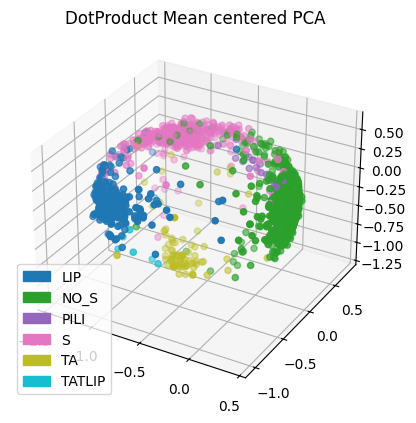

In [8]:
visualizing.evaluation_plots(data,  "DotProduct", label_cols)

torch.Size([3854])
torch.Size([3854, 6])
torch.Size([3854])
tensor([19270,  3854])
CLass accuracy:  [0.93313953 0.98050616 0.84210526 0.93432203 0.88764045 0.83333333]


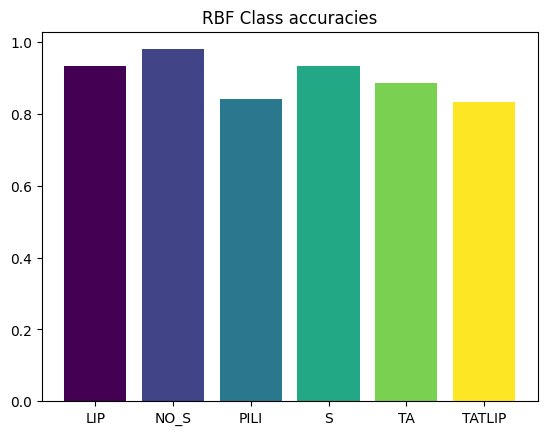

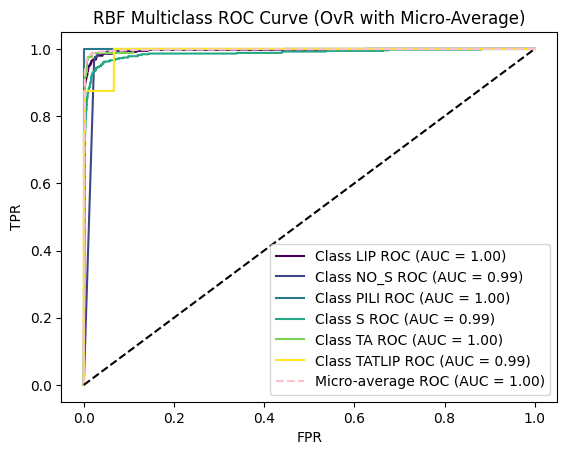

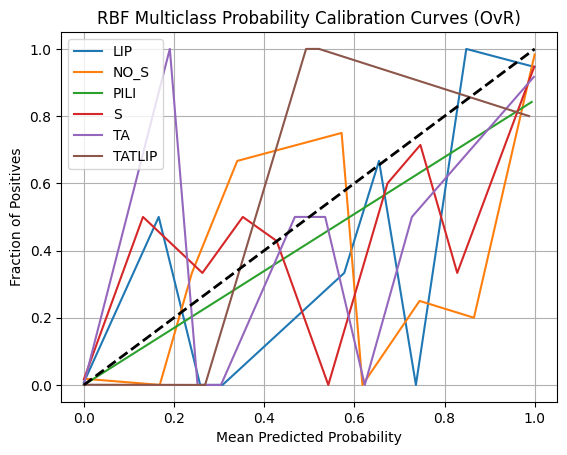

Optimal T: 0.19420522866890513


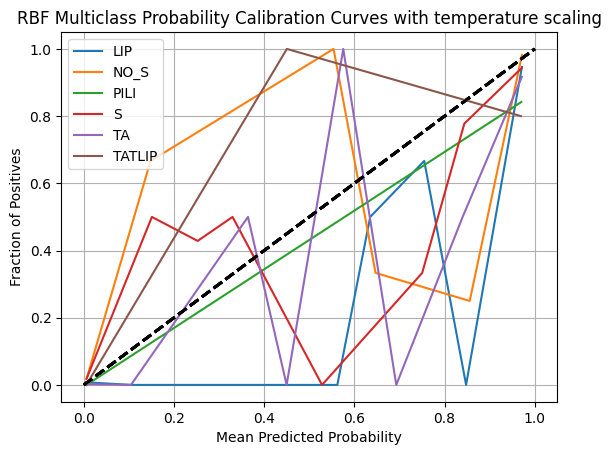

RBF ECE: 0.0043
RBF  MCE: 0.4835
RBF  Brier score: 0.0610
RBF  Log-loss: 0.1809
Variance explained:  [6.2764972e-01 1.8446393e-01 1.1263177e-01 3.2744016e-02 1.3911260e-02
 6.2768045e-03 4.8208921e-03 2.8523360e-03 2.1747523e-03 1.4236760e-03
 1.3156709e-03 1.1914782e-03 7.8319950e-04 7.3276990e-04 6.0640404e-04
 5.1671691e-04 4.7772616e-04 3.9709057e-04 3.4613223e-04 2.9708139e-04
 2.5433587e-04 2.3623205e-04 2.2725527e-04 2.1311521e-04 2.0256116e-04
 1.8674447e-04 1.6567000e-04 1.5166517e-04 1.4508241e-04 1.2850658e-04
 1.2776779e-04 1.2292062e-04 1.0959802e-04 1.0001977e-04 9.5905722e-05
 9.3516712e-05 8.9341702e-05 7.5821808e-05 7.4524833e-05 7.3572170e-05
 7.0103386e-05 6.4034830e-05 6.0566737e-05 5.7112331e-05 5.5820121e-05
 5.0230163e-05 4.9188198e-05 4.8099690e-05 4.6846984e-05 4.5485034e-05
 4.2307802e-05 4.1462928e-05 3.9728020e-05 3.8276456e-05 3.7140439e-05
 3.4159646e-05 3.2540964e-05 3.1822201e-05 3.0728897e-05 2.8702605e-05
 2.7571143e-05 2.6531512e-05 2.5323714e-05 2.43

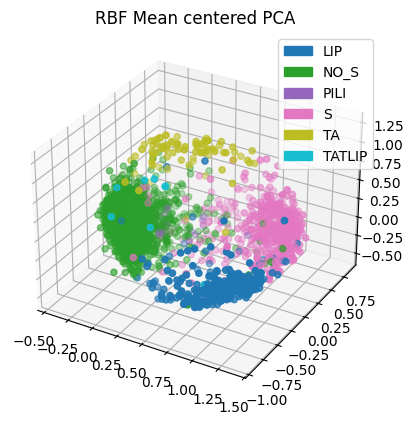

In [11]:
data = torch.load("data/results/signalp_rbf_results.pt")




lab_idx = {'LIP': 0, 'NO_S': 1, 'PILI': 2, 'S': 3, 'TA': 4, 'TATLIP': 5}
label_cols = list(lab_idx.keys())
all_labels_int = data["all_labels"].squeeze(1).cpu() 
all_preds = torch.softmax(data["predictions"], dim=1).cpu()
all_emb = data["embeddings"]
print(all_labels_int.shape)

all_labels = torch.nn.functional.one_hot(all_labels_int, num_classes=6).cpu()
print(all_labels.shape)
all_labels_int = all_labels_int.numpy()
visualizing.evaluation_plots(data,  "RBF", label_cols)